# Telco Customer Churn Prediction: A Data-Driven Approach

## Introduction

In this notebook, we will build a machine learning pipeline to predict customer churn using the Telco Customer Churn dataset. Our workflow includes:
1. **Data Cleaning & Handling Missing Values**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing (Scaling & Encoding)**
4. **Model Training & Evaluation**
5. **Feature Importance Analysis**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. Loading and Inspecting the Data
Let's load our dataset and take an initial look at the features and data types we are working with.

In [2]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning
Upon inspection, the `TotalCharges` column is stored as an object (string) rather than a numeric format. We need to convert this to numeric. During the conversion, any parsing errors will be coerced into `NaN` (null) values, which we will then impute using the mean of the column.

In [4]:
# Convert to numeric and check for nulls
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
# Fill missing values with the mean
mean_value = data['TotalCharges'].mean()
data['TotalCharges'] = data['TotalCharges'].fillna(mean_value)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Exploratory Data Analysis (EDA)
Understanding the distribution of our target variable (`Churn`) and how different features relate to it is essential. We will visualize categorical features using count plots and numerical features using histograms to identify patterns.

In [6]:
# Target Variable Distribution
print(data['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


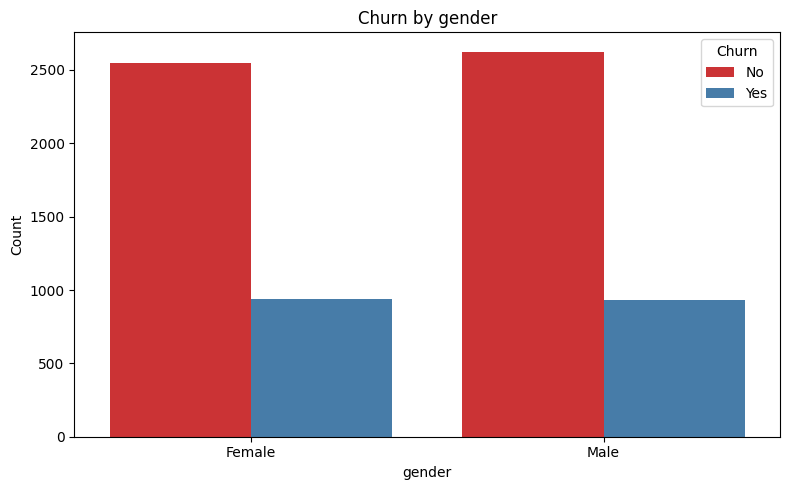

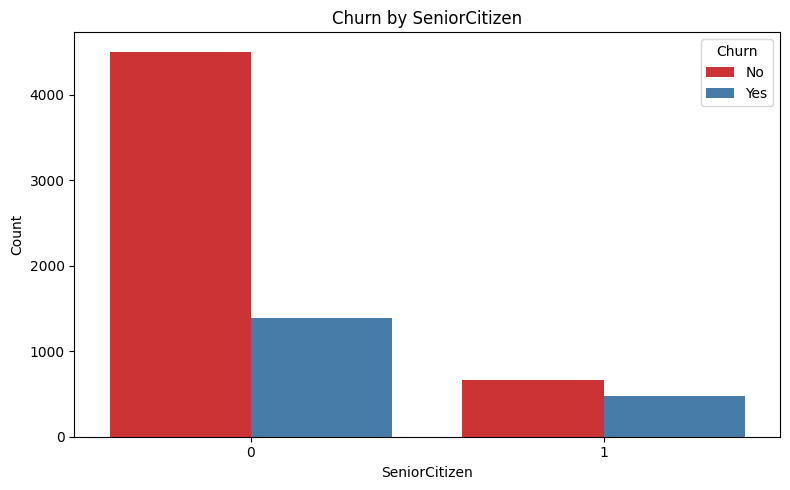

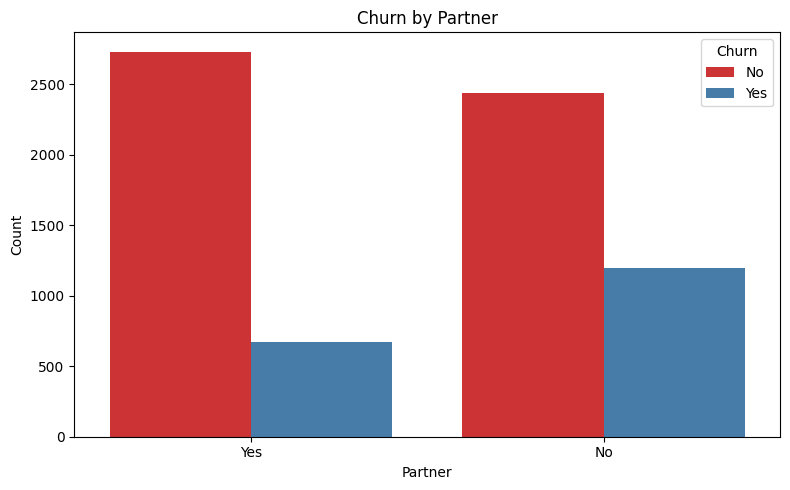

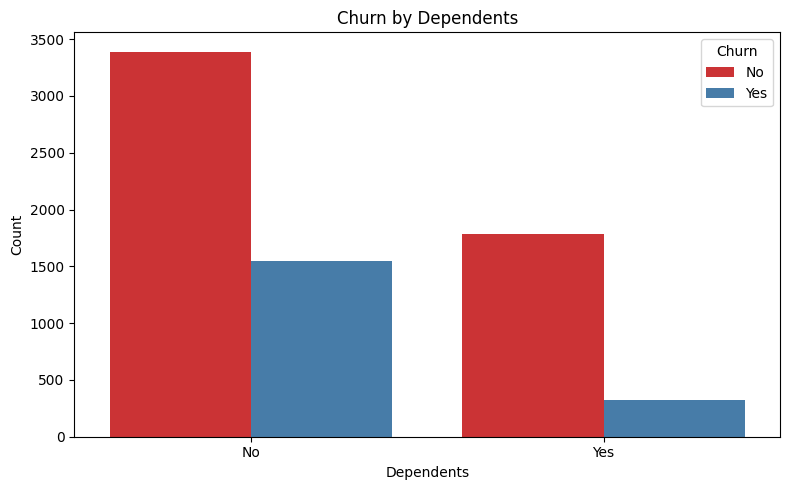

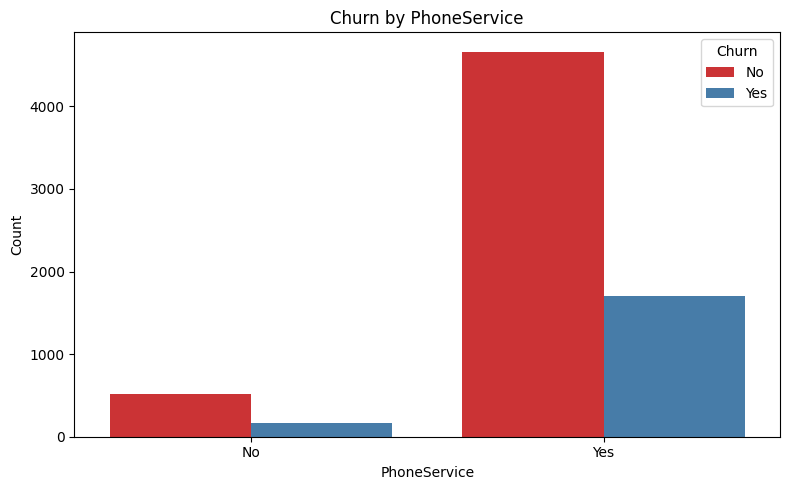

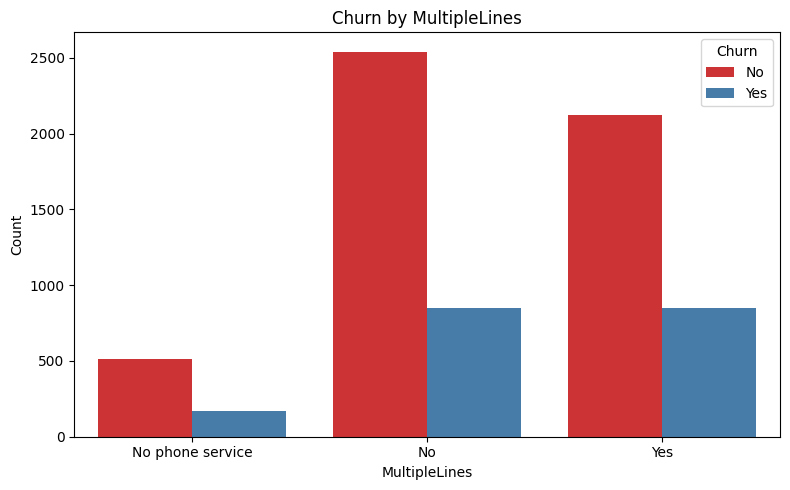

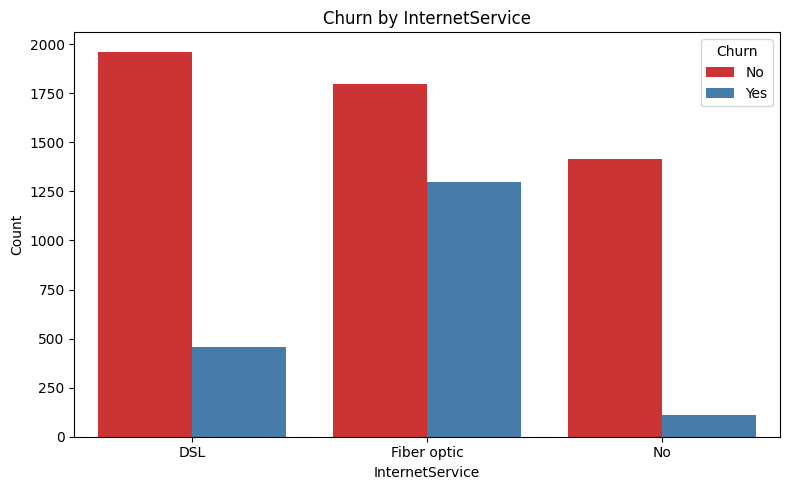

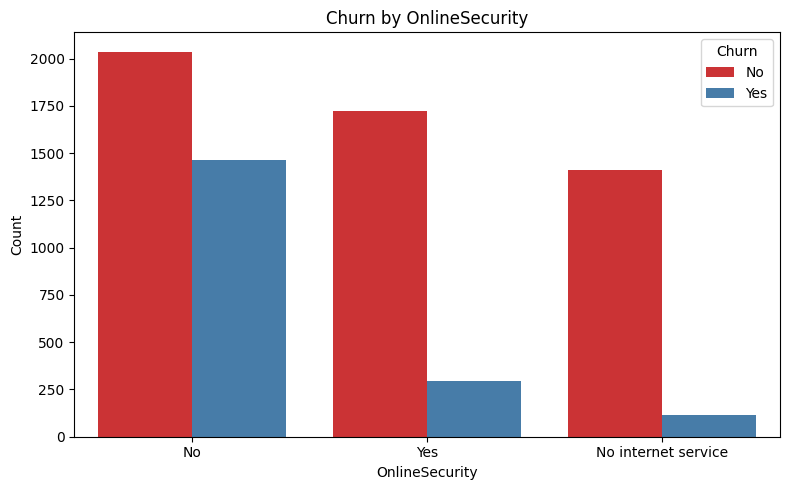

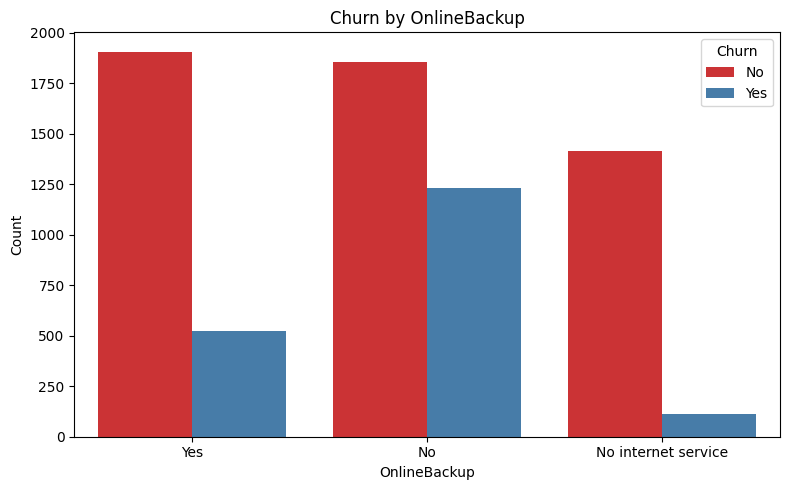

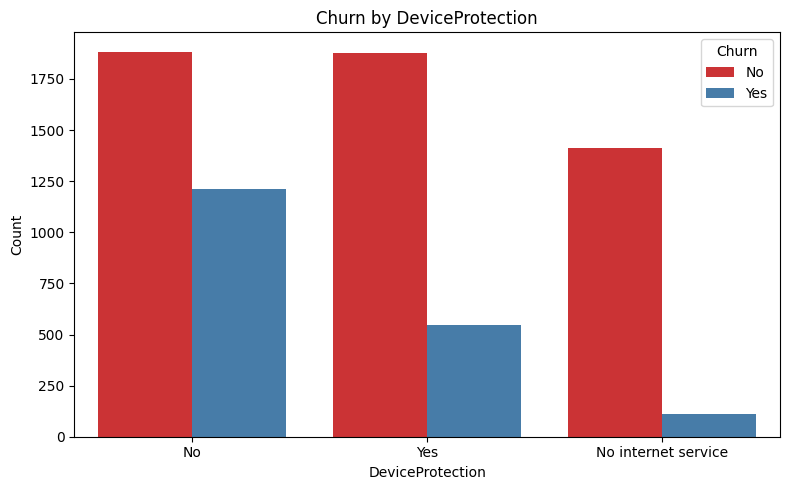

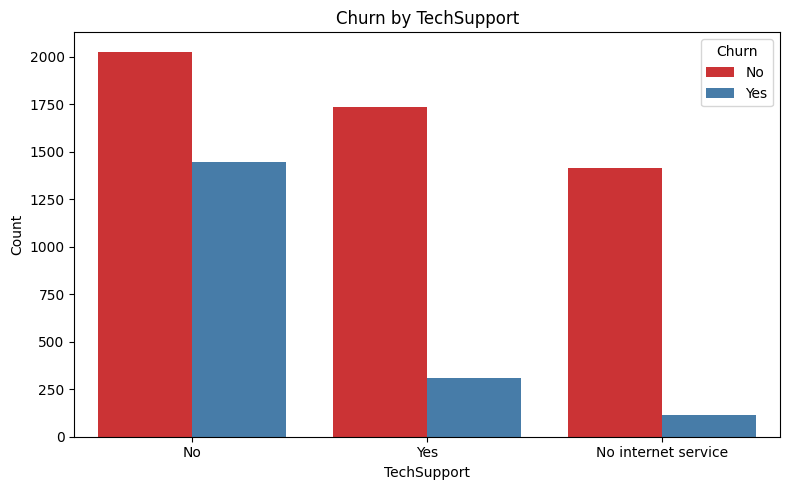

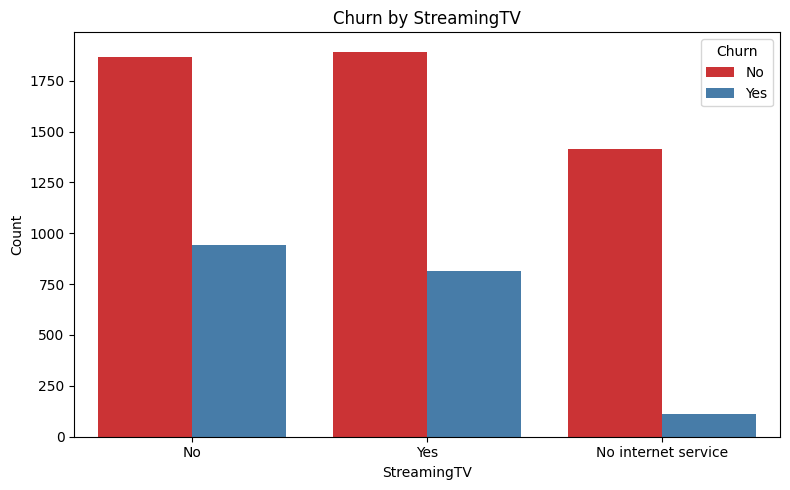

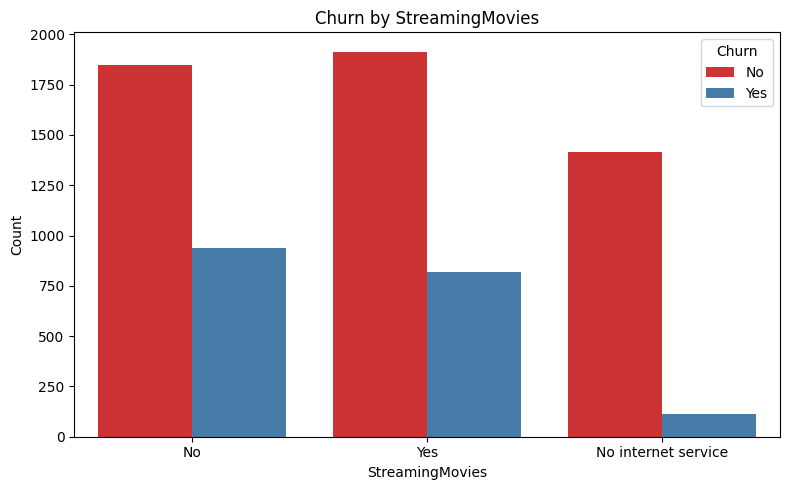

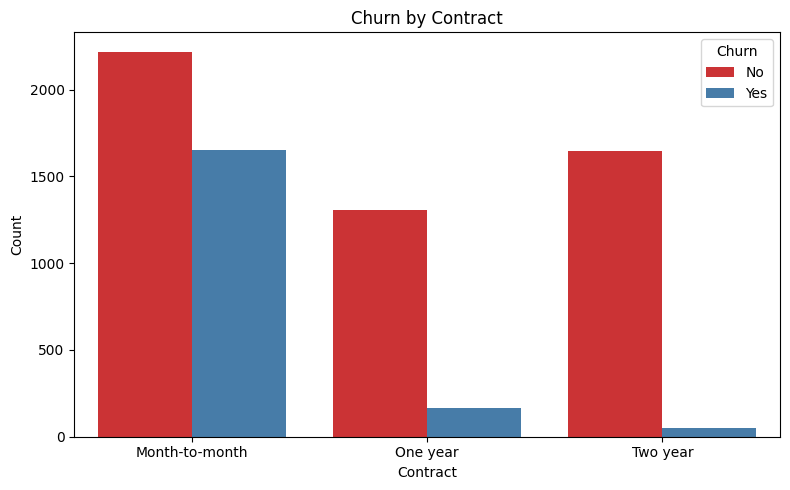

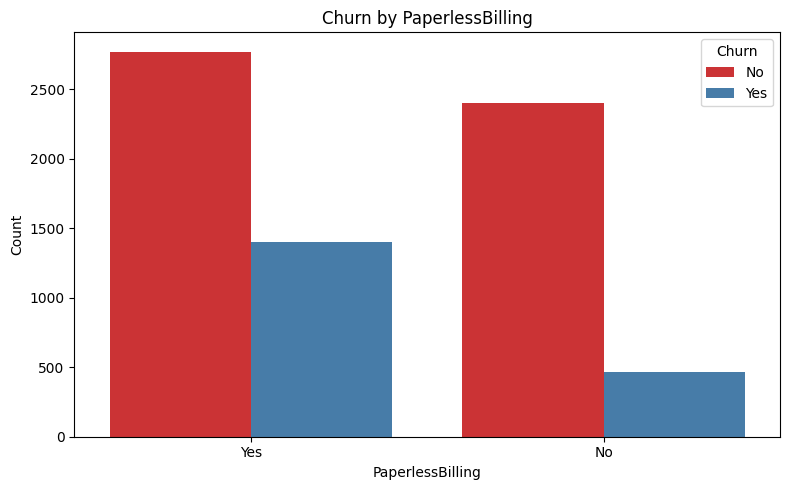

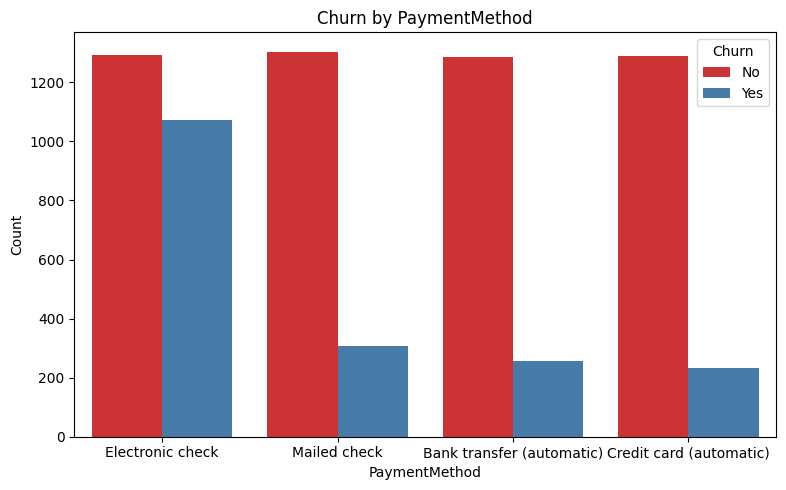

In [7]:
# Categorical Features Visualizations
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='Churn', data=data, palette='Set1')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Churn by {col}')
    plt.tight_layout()
    plt.show()

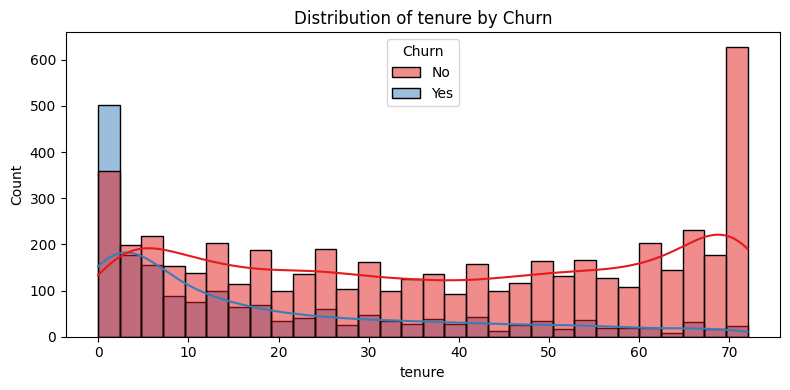

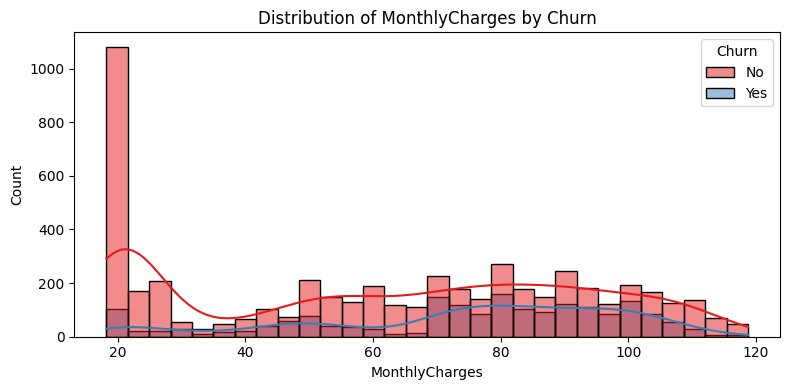

In [8]:
# Numerical Features Visualizations
num_cols = ['tenure', 'MonthlyCharges']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=col, hue='Churn', data=data, bins=30, kde=True, palette='Set1')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col} by Churn')
    plt.tight_layout()
    plt.show()

### Total Charges vs. Churn Heatmap
To see how total charges impact churn, we can bin the `TotalCharges` feature and look at the customer counts across different charge ranges.

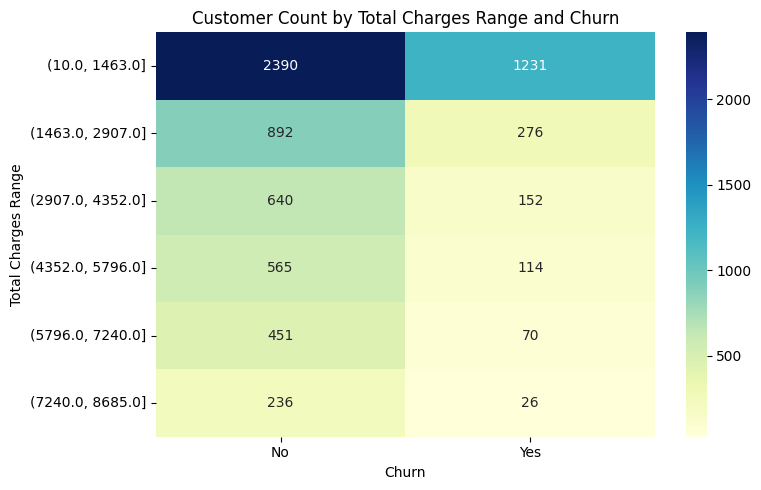

In [9]:
data['TotalCharges_Bin'] = pd.cut(data['TotalCharges'], bins=6, precision=0)

p1 = data.pivot_table(index='TotalCharges_Bin', columns='Churn', aggfunc='size', fill_value=0, observed=False)

plt.figure(figsize=(8, 5))
sns.heatmap(p1, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Churn')
plt.ylabel('Total Charges Range')
plt.title('Customer Count by Total Charges Range and Churn')
plt.tight_layout()

## 4. Data Preprocessing
Before feeding the data into our machine learning algorithms, we must prepare it. This involves:
* Dropping unnecessary columns (like `customerID`).
* Mapping the target variable (`Churn`) to binary numeric values.
* One-hot encoding categorical variables.
* Scaling numerical features using standard scaling so that no single feature dominates the model.

In [10]:
# Drop ID and temporary bin columns
data = data.drop(columns=['customerID', 'TotalCharges_Bin'])

# Map target variable
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical features
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Split features and target
x = data.drop(columns='Churn')
y = data['Churn']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

## 5. Model Building & Evaluation
We will train several classification models and evaluate their performance on our test set. Because churn datasets are often imbalanced, looking at the classification report (precision, recall, f1-score) is just as important as overall accuracy.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=5),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(x_train))
    test_acc  = accuracy_score(y_test,  model.predict(x_test))
    results[name] = {"Train Acc": train_acc, "Test Acc": test_acc}
    print(f"\n--- {name} ---")
    print(f"Train: {train_acc:.3f} | Test: {test_acc:.3f}")
    print(classification_report(y_test, model.predict(x_test), 
          target_names=["No Churn", "Churn"]))


--- Logistic Regression ---
Train: 0.754 | Test: 0.739
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Decision Tree ---
Train: 0.801 | Test: 0.794
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409


--- Random Forest ---
Train: 0.752 | Test: 0.737
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.81      0.62       374

    accuracy              

## 6. Feature Importance
Let's extract the feature importances from our Random Forest model to understand what factors are the strongest indicators of a customer churning.

Top 5 Features driving Churn:
                           Feature  Importance
0                           tenure    0.197345
25               Contract_Two year    0.150374
2                     TotalCharges    0.098607
10     InternetService_Fiber optic    0.098334
28  PaymentMethod_Electronic check    0.076393



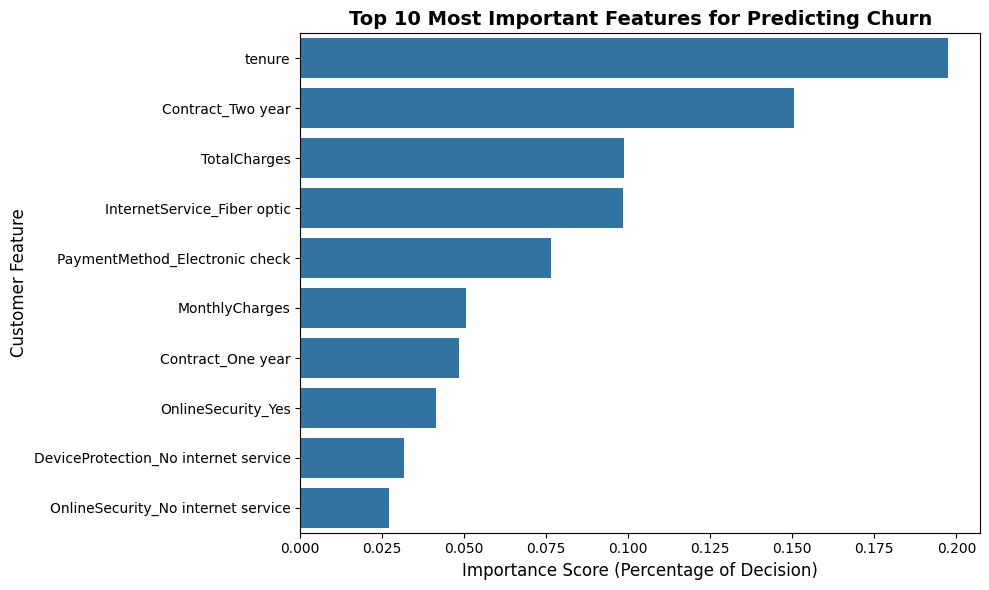

In [12]:
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_

feature_names = x_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 5 Features driving Churn:")
print(importance_df.head(5))
print()

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))

plt.title('Top 10 Most Important Features for Predicting Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Percentage of Decision)', fontsize=12)
plt.ylabel('Customer Feature', fontsize=12)
plt.tight_layout()

## Conclusion
By comparing different models, we can see how baseline models like Logistic Regression hold up against tree-based ensemble methods. Our feature importance analysis highlights that business metrics like **tenure and contract type** are the heaviest drivers of customer churn. With this knowledge, targeted retention strategies can be developed to intervene before a high-risk customer leaves.